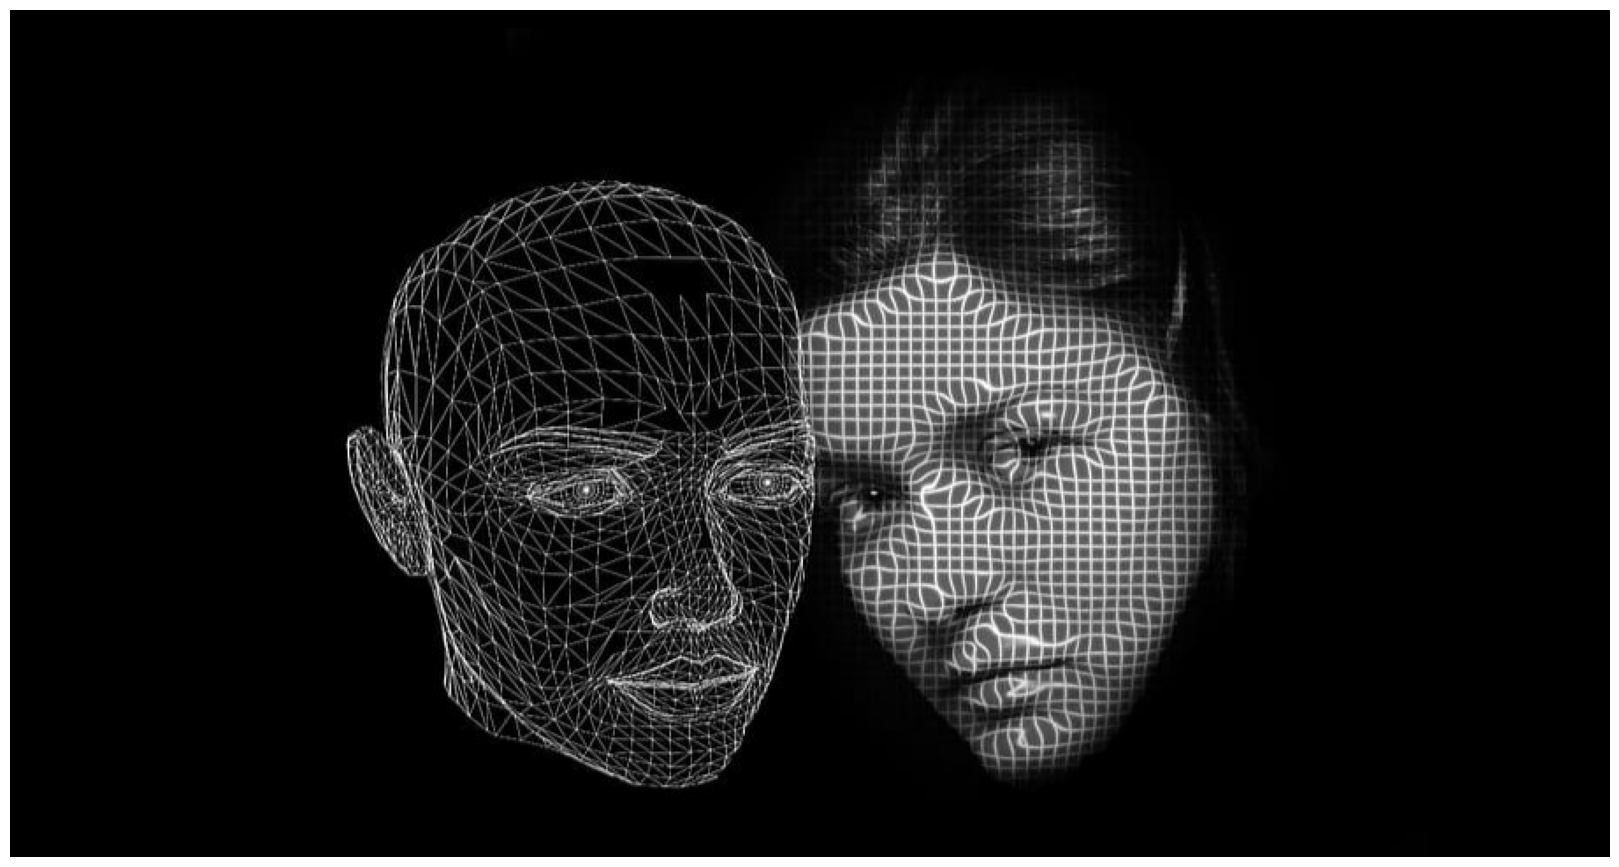

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread(r"C:\Users\swathy\OneDrive\Desktop\swathy DSA\psychology-psyche-mask-wire-rack.jpg")

plt.figure(figsize=(22, 11))   # Bigger = larger image
plt.imshow(img)
plt.axis('off')
plt.show()

<div style="
    background: linear-gradient(135deg, #0f0a47, #153fa8);
    color: #d8f3ee;
    font-weight: bold;
    padding: 24px 20px;
    border-radius: 18px;
    text-align: center;
    font-size: 55px;
    letter-spacing: 1.8px;
    text-transform: uppercase;
    box-shadow: 0 3px 12px rgba(15, 10, 71, 0.5);
    text-shadow: 0 0 2px #c4e600, 0 0 6px rgba(196, 230, 0, 0.6);
    border: 2px solid rgba(255, 255, 255, 0.12);
">
PREDICTIVE MODELING ON PERSONALITY DATASET
</div>

<div style="
    background: linear-gradient(135deg, #0f0a47, #153fa8);
    color: #d8f3ee;
    font-weight: bold;
    padding: 24px 20px;
    border-radius: 18px;
    text-align: center;
    font-size: 35px;
    letter-spacing: 1.8px;
    text-transform: uppercase;
    box-shadow: 0 3px 12px rgba(15, 10, 71, 0.5);
    text-shadow: 0 0 2px #c4e600, 0 0 6px rgba(196, 230, 0, 0.6);
    border: 2px solid rgba(255, 255, 255, 0.12);
">
IMPORT LIBRARIES & ALGORITHMS
</div>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.preprocessing import StandardScaler,LabelEncoder

In [ ]:
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [ ]:
from tabulate import tabulate

In [ ]:
from sklearn.model_selection import RandomizedSearchCV,GridSearchCV

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

<div style="
    background: linear-gradient(135deg, #0f0a47, #153fa8);
    color: #d8f3ee;
    font-weight: bold;
    padding: 24px 20px;
    border-radius: 18px;
    text-align: center;
    font-size: 40px;
    letter-spacing: 1.8px;
    text-transform: uppercase;
    box-shadow: 0 3px 12px rgba(15, 10, 71, 0.5);
    text-shadow: 0 0 2px #c4e600, 0 0 6px rgba(196, 230, 0, 0.6);
    border: 2px solid rgba(255, 255, 255, 0.12);
">
  LOAD DATASET
</div>


In [ ]:
pn=pd.read_csv(r"C:\Users\swathy\OneDrive\Desktop\swathy DSA\PairDrop_files_2025  (CSV)\personality data.csv")
pn

,Age,Gender,Education,Introversion Score,Sensing Score,Thinking Score,Judging Score,Interest,Personality
0,21.0,Female,1,5.89208,2.144395,7.32363,5.462224,Arts,ENTP
1,24.0,Female,1,2.48366,3.206188,8.06876,3.765012,Unknown,INTP
2,26.0,Female,1,7.02910,6.469302,4.16472,5.454442,Others,ESFP
3,30.0,Male,0,5.46525,4.179244,2.82487,5.080477,Sports,ENFJ
4,31.0,Female,0,3.59804,6.189259,5.31347,3.677984,Others,ISFP
...,...,...,...,...,...,...,...,...,...
43739,26.0,Male,1,8.88656,5.118399,8.48784,5.331942,Arts,ENTP
43740,29.0,Male,0,2.71470,6.851956,0.25519,3.623678,Unknown,ISFP
43741,25.0,Female,0,2.00982,6.544036,6.63911,6.201555,Technology,ISTJ
43742,23.0,Male,0,7.23553,4.876780,2.41671,4.654016,Arts,ENFP


<style>
td, th {
    padding:10px;
    border:1px solid #cce6cc;
    color:#222222;           /* Darker font */
    font-weight:500;         /* Slightly bold for readability */
}

th {
    background:#5FA86D;      /* Medium green header */
    color:white;             /* White text */
    font-weight:600;         /* Darker/bolder header */
}

tr:nth-child(even) {
    background:#E8F5E9;      /* Light green */
}

tr:nth-child(odd) {
    background:#FFFFFF;      /* White */
}

table {
    border-collapse: collapse;
    width:70%;
    font-family: Arial, sans-serif;
    font-size:16px;          /* Slightly larger for clarity */
}
</style>

<table>
<tr>
<th>Column Name</th>
<th>Meaning / Description</th>
</tr>

<tr>
<td><b>Age</b></td>
<td>Age of the person (in years).</td>
</tr>

<tr>
<td><b>Gender</b></td>
<td>Gender of the person (Male / Female).</td>
</tr>

<tr>
<td><b>Education</b></td>
<td>Education level coded as numbers (example: 0 = not graduated, 1 = graduated — depends on project coding).</td>
</tr>

<tr>
<td><b>Introversion Score</b></td>
<td>Score that shows how introverted the person is (higher score = more introverted).</td>
</tr>

<tr>
<td><b>Sensing Score</b></td>
<td>Score that shows focus on practical/real information vs intuition.</td>
</tr>

<tr>
<td><b>Thinking Score</b></td>
<td>Score that shows thinking-style decision making (logic vs emotion).</td>
</tr>

<tr>
<td><b>Judging Score</b></td>
<td>Score that shows structured vs flexible personality traits.</td>
</tr>

<tr>
<td><b>Interest</b></td>
<td>Category of hobby or interest of the person (Arts, Sports, Others, etc.).</td>
</tr>

<tr>
<td><b>Personality</b></td>
<td>Final personality type (like INTP, ENFJ, ISFP, etc.).</td>
</tr>

</table>


<style>
/* Container box */
.box {
    background:#E8F5E9;               /* Light green background */
    padding:20px;
    border:2px solid #cce6cc;         /* Soft mint border */
    border-radius:12px;
    width:60%;
    font-family: Arial, sans-serif;
    color:#1f1f1f;                    /* Darker readable font */
    font-size:16px;
}

/* Section titles */
.section-title {
    background:#5FA86D;               /* Medium green */
    color:white;
    padding:8px 12px;
    border-radius:6px;
    font-weight:600;
    margin-bottom:8px;
}

/* Bullet list */
ul.custom-list {
    list-style-type: "✔ ";           /* Green tick-style bullets */
    padding-left:25px;
    line-height:1.8;
    font-weight:500;
    color:#2d2d2d;
}
</style>

<div class="box">

<div class="section-title">🔹 Demographic Columns:</div>
<ul class="custom-list">
    <li>Gender</li>
    <li>Interest</li>
</ul>

<div class="section-title">🔹 Psychological Score Columns:</div>
<ul class="custom-list">
    <li>Introversion Score</li>
    <li>Sensing Score</li>
    <li>Thinking Score</li>
    <li>Judging Score</li>
</ul>

<div class="section-title">🔹 Target Column:</div>
<ul class="custom-list">
    <li>Personality</li>
</ul>

</div>


<style>
td, th {
    padding:10px;
    border:1px solid #cce6cc;
    color:#222222;           /* Darker font */
    font-weight:500;         /* Slightly bold for readability */
}

th {
    background:#5FA86D;      /* Medium green header */
    color:white;             /* White text */
    font-weight:600;         /* Darker/bolder header */
}

tr:nth-child(even) {
    background:#E8F5E9;      /* Light green */
}

tr:nth-child(odd) {
    background:#FFFFFF;      /* White */
}

table {
    border-collapse: collapse;
    width:70%;
    font-family: Arial, sans-serif;
    font-size:16px;          /* Slightly larger for clarity */
}

</style>




| Letter    | Stands For                  | Trait Meaning                              |
| --------- | --------------------------- | ------------------------------------------ |
| **E / I** | Extraversion / Introversion | Focus on the outer world vs inner world    |
| **S / N** | Sensing / Intuition         | Practical information vs big-picture ideas |
| **T / F** | Thinking / Feeling          | Logic-based vs emotion-based decisions     |
| **J / P** | Judging / Perceiving        | Organized/planful vs flexible/spontaneous  |


<style>
td, th {
    padding:10px;
    border:1px solid #cce6cc;
    color:#222222;           /* Darker font */
    font-weight:500;         /* Slightly bold for readability */
}

th {
    background:#5FA86D;      /* Medium green header */
    color:white;             /* White text */
    font-weight:600;         /* Darker/bolder header */
}

tr:nth-child(even) {
    background:#E8F5E9;      /* Light green */
}

tr:nth-child(odd) {
    background:#FFFFFF;      /* White */
}

table {
    border-collapse: collapse;
    width:70%;
    font-family: Arial, sans-serif;
    font-size:16px;          /* Slightly larger for clarity */
}

</style>




| Personality Type | Meaning (Simple Words)                                        |
| ---------------- | ------------------------------------------------------------- |
| **ENTP**         | Outgoing, creative, loves ideas and debates.                  |
| **INTP**         | Quiet thinker, loves problem-solving and logic.               |
| **ESFP**         | Fun-loving, energetic, loves people and entertainment.        |
| **ENFJ**         | Caring leader, good at guiding and helping others.            |
| **ISFP**         | Calm, artistic, kind, likes peaceful life.                    |
| **ISFJ**         | Responsible, supportive, loves traditions and helping others. |
| **ESTJ**         | Organized, practical, strong leadership, follows rules.       |
| **INFP**         | Emotional, imaginative, deeply caring about values.           |
| **ESTP**         | Action-oriented, adventurous, loves excitement and risk.      |
| **ENFP**         | Enthusiastic, friendly, creative, strong imagination.         |
| **INTJ**         | Smart strategist, independent, long-term planner.             |
| **ESFJ**         | Social, helpful, loves teamwork and harmony.                  |
| **ISTJ**         | Practical, serious, detail-oriented, trustworthy.             |
| **INFJ**         | Deep thinker with strong values, wants to improve the world.  |
| **ISTP**         | Quiet doer, hands-on problem solver, likes fixing things.     |
| **ENTJ**         | Confident leader, strong decision-maker, goal oriented.       |


<div style="
    background: linear-gradient(135deg, #0f0a47, #153fa8);
    color: #d8f3ee;
    font-weight: bold;
    padding: 24px 20px;
    border-radius: 18px;
    text-align: center;
    font-size: 40px;
    letter-spacing: 1.8px;
    text-transform: uppercase;
    box-shadow: 0 3px 12px rgba(15, 10, 71, 0.5);
    text-shadow: 0 0 2px #c4e600, 0 0 6px rgba(196, 230, 0, 0.6);
    border: 2px solid rgba(255, 255, 255, 0.12);
">
  DATA PRE-PROCESSING
</div>


In [ ]:
pn.shape

(43744, 9)

In [ ]:
for i in pn:
    print(f'Unique Values of {i} :')
    print(pn[i].unique())
    print(f'Minimum of Vlue {i} :')
    print(pn[i].min())
    print(f'Maximum of Value {i} :')
    print(pn[i].max())
    print(f'No. of Unique Value {i} :')
    print(pn[i].nunique(),'\n\n\n\n')

Unique Values of Age :
[21. 24. 26. 30. 31. 33. 32. 27. 28. 40. 43. 25. 29. 34. 23. 22. 20. 36.
 41. 35. 19. 38. 39. 37. 45. 18. 44. 42. 49. 47. 48. 52. 51. 46. 50.]
Minimum of Vlue Age :
18.0
Maximum of Value Age :
52.0
No. of Unique Value Age :
35 




Unique Values of Gender :
['Female' 'Male']
Minimum of Vlue Gender :
Female
Maximum of Value Gender :
Male
No. of Unique Value Gender :
2 




Unique Values of Education :
[1 0]
Minimum of Vlue Education :
0
Maximum of Value Education :
1
No. of Unique Value Education :
2 




Unique Values of Introversion Score :
[5.89208 2.48366 7.0291  ... 2.7147  7.23553 1.8831 ]
Minimum of Vlue Introversion Score :
0.00015
Maximum of Value Introversion Score :
9.99992
No. of Unique Value Introversion Score :
41766 




Unique Values of Sensing Score :
[2.14439454 3.20618821 6.46930208 ... 6.85195595 4.87677953 4.05564202]
Minimum of Vlue Sensing Score :
0.0
Maximum of Value Sensing Score :
9.80383711729579
No. of Unique Value Sensing Score :
42715

In [ ]:
pn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43744 entries, 0 to 43743
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 43744 non-null  float64
 1   Gender              43744 non-null  object 
 2   Education           43744 non-null  int64  
 3   Introversion Score  43744 non-null  float64
 4   Sensing Score       43744 non-null  float64
 5   Thinking Score      43744 non-null  float64
 6   Judging Score       43744 non-null  float64
 7   Interest            43744 non-null  object 
 8   Personality         43744 non-null  object 
dtypes: float64(5), int64(1), object(3)
memory usage: 3.0+ MB


In [ ]:
pn.describe(include='all')

,Age,Gender,Education,Introversion Score,Sensing Score,Thinking Score,Judging Score,Interest,Personality
count,43744.000000,43744,43744.000000,43744.000000,43744.000000,43744.000000,43744.000000,43744,43744
unique,NaN,2,NaN,NaN,NaN,NaN,NaN,5,16
top,NaN,Male,NaN,NaN,NaN,NaN,NaN,Unknown,ENTP
freq,NaN,24155,NaN,NaN,NaN,NaN,NaN,15396,2734
mean,27.437203,NaN,0.229014,4.588349,5.780074,5.419131,5.391041,NaN,NaN
std,4.893805,NaN,0.420203,2.902628,1.241648,2.900785,1.442413,NaN,NaN
min,18.000000,NaN,0.000000,0.000150,0.000000,0.000320,0.000000,NaN,NaN
25%,24.000000,NaN,0.000000,2.067020,4.953340,2.895750,4.511842,NaN,NaN
50%,27.000000,NaN,0.000000,4.261680,6.162928,5.769870,5.771635,NaN,NaN
75%,30.000000,NaN,0.000000,7.085002,6.622978,7.923503,6.409583,NaN,NaN


In [ ]:
pn.isna().sum()

Age                   0
Gender                0
Education             0
Introversion Score    0
Sensing Score         0
Thinking Score        0
Judging Score         0
Interest              0
Personality           0
dtype: int64

<div style="
    background: linear-gradient(135deg, #0f0a47, #153fa8);
    color: #d8f3ee;
    font-weight: bold;
    padding: 44px 20px;
    border-radius: 18px;
    text-align: center;
    font-size: 50px;
    letter-spacing: 1.8px;
    text-transform: uppercase;
    box-shadow: 0 3px 12px rgba(15, 10, 71, 0.5);
    text-shadow: 0 0 2px #c4e600, 0 0 6px rgba(196, 230, 0, 0.6);
    border: 2px solid rgba(255, 255, 255, 0.12);
">
  EDA
</div>

<div style="
    background: linear-gradient(135deg, #110c46ff, #2e4786ff);
    color: #d8f3ee;
    font-weight: bold;
    padding: 24px 20px;
    border-radius: 18px;
    text-align: center;
    font-size: 40px;
    letter-spacing: 1.8px;
    text-transform: uppercase;
    box-shadow: 0 3px 8px rgba(15, 10, 71, 0.5);
    text-shadow: 0 0 2px #c4e600, 0 0 6px rgba(196, 230, 0, 0.6);
    border: 2px solid rgba(255, 255, 255, 0.12);
">
  DATA VISUALIZTAION
</div>  

<div style="
    background: linear-gradient(135deg, rgba(21, 50, 49, 0.6), #0f5d5aff);
    color: #8ec67aff;
    font-weight: bold;
    padding: 25px 25px;
    border-radius: 15px;
    text-align: left;
    font-size: 35px;
    letter-spacing: 1.8px;
    text-transform: uppercase;
    box-shadow: 0 3px 12px rgba(15, 10, 71, 0.5);
    text-shadow: 0 0 1px #d5d5d5ff, 0 0 3px #0f0a47;
    border: 2px solid rgba(255, 255, 255, 0.12);
">
UNI-VARIATE        
</div>   

<div style="
    background: linear-gradient(135deg, rgba(21, 198, 195, 0.6), #08add6ff);
    color: #153fa8;
    font-weight: bold;
    padding: 24px 20px;
    border-radius: 18px;
    text-align: left;
    font-size: 28px;
    letter-spacing: 1.8px;
    text-transform: uppercase;
    box-shadow: 0 3px 12px rgba(15, 10, 71, 0.5);
    text-shadow: 0 0 1px #d5d5d5ff, 0 0 3px #0f0a47;
    border: 2px solid rgba(255, 255, 255, 0.12);
">
  HISTPLOT
</div>


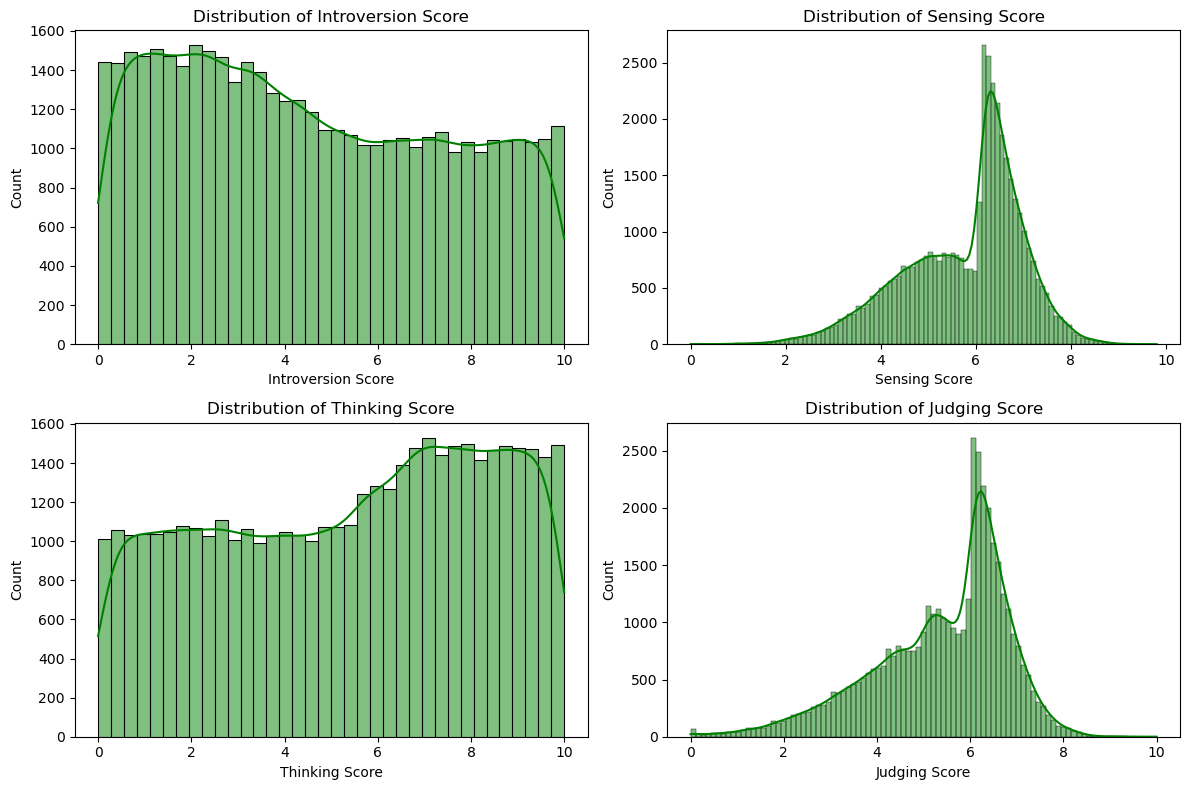

In [ ]:
score_cols = ["Introversion Score","Sensing Score","Thinking Score","Judging Score"]

plt.figure(figsize=(12,8))
for i, col in enumerate(score_cols, 1):
    plt.subplot(2,2,i)
    sns.histplot(pn[col], kde=True,color='Green')
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

<div style="
    background: linear-gradient(135deg, rgba(21, 198, 195, 0.6), #08add6ff);
    color: #153fa8;
    font-weight: bold;
    padding: 24px 20px;
    border-radius: 18px;
    text-align: left;
    font-size: 28px;
    letter-spacing: 1.8px;
    text-transform: uppercase;
    box-shadow: 0 3px 12px rgba(15, 10, 71, 0.5);
    text-shadow: 0 0 1px #d5d5d5ff, 0 0 3px #0f0a47;
    border: 2px solid rgba(255, 255, 255, 0.12);
">
  BOXPLOT
</div>


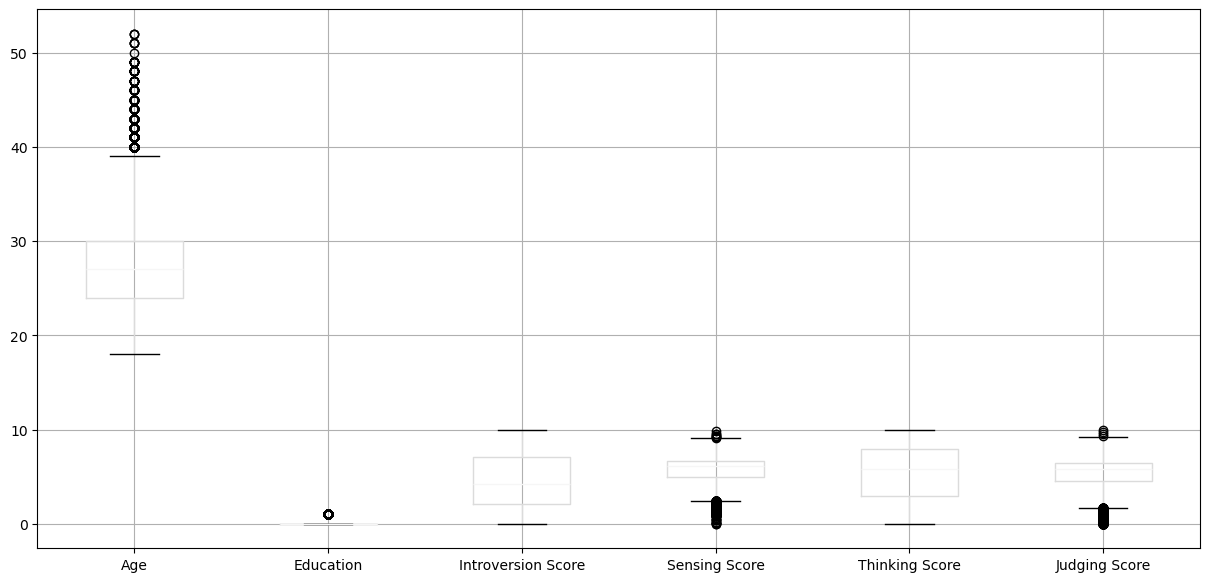

In [ ]:
num=pn.select_dtypes('number')
plt.figure(figsize=(15,7))
num.boxplot()
plt.show()

<div style="
    background: linear-gradient(135deg, rgba(21, 198, 195, 0.6), #08add6ff);
    color: #153fa8;
    font-weight: bold;
    padding: 24px 20px;
    border-radius: 18px;
    text-align: left;
    font-size: 28px;
    letter-spacing: 1.8px;
    text-transform: uppercase;
    box-shadow: 0 3px 12px rgba(15, 10, 71, 0.5);
    text-shadow: 0 0 1px #d5d5d5ff, 0 0 3px #0f0a47;
    border: 2px solid rgba(255, 255, 255, 0.12);
">
  COUNTPLOT
</div>


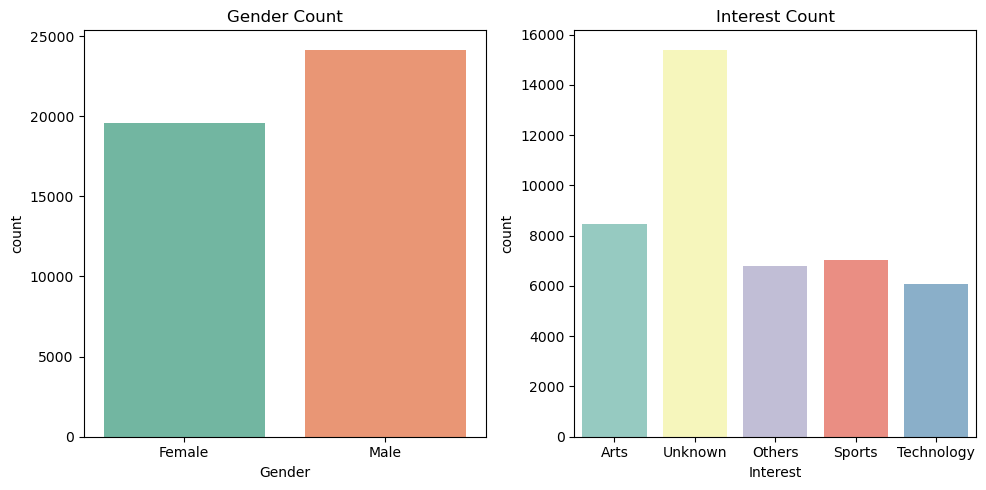

In [ ]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
sns.countplot(x="Gender", data=pn, palette="Set2")
plt.title("Gender Count")

plt.subplot(1,2,2)
sns.countplot(x="Interest", data=pn, palette="Set3")
plt.title("Interest Count")

plt.tight_layout()
plt.show()

<div style="
    background: linear-gradient(135deg, rgba(21, 50, 49, 0.6), #0f5d5aff);
    color: #8ec67aff;
    font-weight: bold;
    padding: 25px 25px;
    border-radius: 15px;
    text-align: left;
    font-size: 35px;
    letter-spacing: 1.8px;
    text-transform: uppercase;
    box-shadow: 0 3px 12px rgba(15, 10, 71, 0.5);
    text-shadow: 0 0 1px #d5d5d5ff, 0 0 3px #0f0a47;
    border: 2px solid rgba(255, 255, 255, 0.12);
">
BI-VARIATE        
</div>   

<div style="
    background: linear-gradient(135deg, rgba(21, 198, 195, 0.6), #08add6ff);
    color: #153fa8;
    font-weight: bold;
    padding: 24px 20px;
    border-radius: 18px;
    text-align: left;
    font-size: 28px;
    letter-spacing: 1.8px;
    text-transform: uppercase;
    box-shadow: 0 3px 12px rgba(15, 10, 71, 0.5);
    text-shadow: 0 0 1px #d5d5d5ff, 0 0 3px #0f0a47;
    border: 2px solid rgba(255, 255, 255, 0.12);
">
  VIOLIN PLOT
</div>


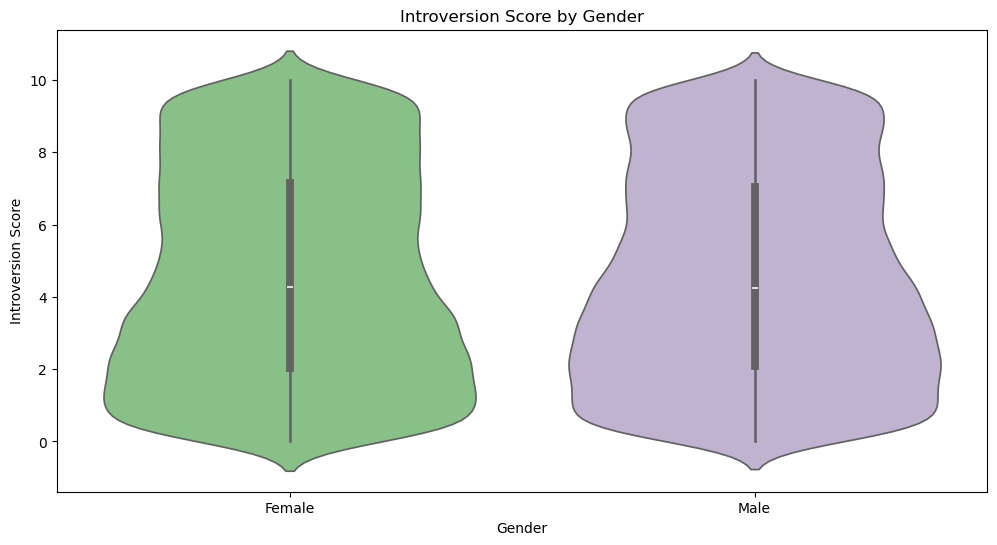

In [ ]:
plt.figure(figsize=(12,6))
sns.violinplot(x="Gender", y="Introversion Score", data=pn, palette="Accent")
plt.title("Introversion Score by Gender")
plt.show()

<div style="
    background: linear-gradient(135deg, rgba(21, 50, 49, 0.6), #0f5d5aff);
    color: #8ec67aff;
    font-weight: bold;
    padding: 25px 25px;
    border-radius: 15px;
    text-align: left;
    font-size: 35px;
    letter-spacing: 1.8px;
    text-transform: uppercase;
    box-shadow: 0 3px 12px rgba(15, 10, 71, 0.5);
    text-shadow: 0 0 1px #d5d5d5ff, 0 0 3px #0f0a47;
    border: 2px solid rgba(255, 255, 255, 0.12);
">
MULTI-VARIATE        
</div>   

<div style="
    background: linear-gradient(135deg, rgba(21, 198, 195, 0.6), #08add6ff);
    color: #153fa8;
    font-weight: bold;
    padding: 24px 20px;
    border-radius: 18px;
    text-align: left;
    font-size: 28px;
    letter-spacing: 1.8px;
    text-transform: uppercase;
    box-shadow: 0 3px 12px rgba(15, 10, 71, 0.5);
    text-shadow: 0 0 1px #d5d5d5ff, 0 0 3px #0f0a47;
    border: 2px solid rgba(255, 255, 255, 0.12);
">
  HEAT MAP
</div>


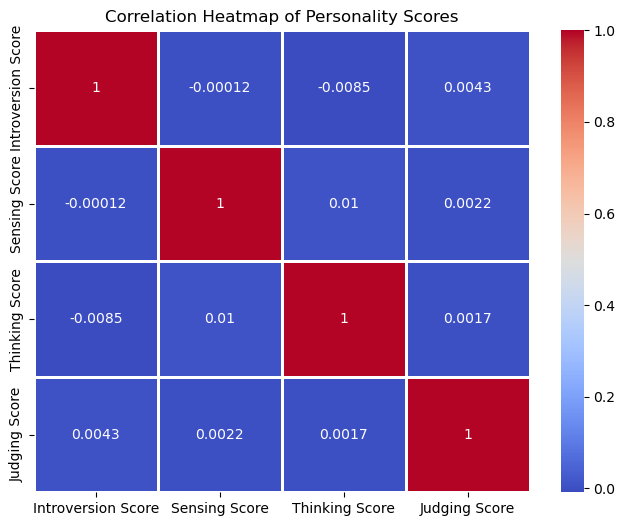

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(pn[score_cols].corr(), annot=True, cmap="coolwarm", linewidths=2)
plt.title("Correlation Heatmap of Personality Scores")
plt.show()

<div style="
    background: linear-gradient(135deg, #0f0a47, #153fa8);
    color: #d8f3ee;
    font-weight: bold;
    padding: 24px 20px;
    border-radius: 10px;
    text-align: center;
    font-size: 35px;
    letter-spacing: 1.8px;
    text-transform: uppercase;
    box-shadow: 0 3px 12px rgba(15, 10, 71, 0.5);
    text-shadow: 0 0 2px #c4e600, 0 0 6px rgba(196, 230, 0, 0.6);
    border: 2px solid rgba(255, 255, 255, 0.12);
">
   FEATURE ENGERING
</div>


In [ ]:
pn.Personality.unique()

array(['ENTP', 'INTP', 'ESFP', 'ENFJ', 'ISFP', 'ISFJ', 'ESTJ', 'INFP',
       'ESTP', 'ENFP', 'INTJ', 'ESFJ', 'ISTJ', 'INFJ', 'ISTP', 'ENTJ'],
      dtype=object)

In [ ]:
pn_copy=pn.copy()
pn_copy

,Age,Gender,Education,Introversion Score,Sensing Score,Thinking Score,Judging Score,Interest,Personality
0,21.0,Female,1,5.89208,2.144395,7.32363,5.462224,Arts,ENTP
1,24.0,Female,1,2.48366,3.206188,8.06876,3.765012,Unknown,INTP
2,26.0,Female,1,7.02910,6.469302,4.16472,5.454442,Others,ESFP
3,30.0,Male,0,5.46525,4.179244,2.82487,5.080477,Sports,ENFJ
4,31.0,Female,0,3.59804,6.189259,5.31347,3.677984,Others,ISFP
...,...,...,...,...,...,...,...,...,...
43739,26.0,Male,1,8.88656,5.118399,8.48784,5.331942,Arts,ENTP
43740,29.0,Male,0,2.71470,6.851956,0.25519,3.623678,Unknown,ISFP
43741,25.0,Female,0,2.00982,6.544036,6.63911,6.201555,Technology,ISTJ
43742,23.0,Male,0,7.23553,4.876780,2.41671,4.654016,Arts,ENFP


In [ ]:
pn_copy["Avg_Score"] = pn_copy[["Introversion Score","Sensing Score","Thinking Score","Judging Score"]].mean(axis=1)

In [ ]:
pn_copy["Activeness"] = pn_copy["Personality"].str.extract(r'^([EI])', expand=False)
pn_copy

,Age,Gender,Education,Introversion Score,Sensing Score,Thinking Score,Judging Score,Interest,Personality,Avg_Score,Activeness
0,21.0,Female,1,5.89208,2.144395,7.32363,5.462224,Arts,ENTP,5.205582,E
1,24.0,Female,1,2.48366,3.206188,8.06876,3.765012,Unknown,INTP,4.380905,I
2,26.0,Female,1,7.02910,6.469302,4.16472,5.454442,Others,ESFP,5.779391,E
3,30.0,Male,0,5.46525,4.179244,2.82487,5.080477,Sports,ENFJ,4.387460,E
4,31.0,Female,0,3.59804,6.189259,5.31347,3.677984,Others,ISFP,4.694688,I
...,...,...,...,...,...,...,...,...,...,...,...
43739,26.0,Male,1,8.88656,5.118399,8.48784,5.331942,Arts,ENTP,6.956185,E
43740,29.0,Male,0,2.71470,6.851956,0.25519,3.623678,Unknown,ISFP,3.361381,I
43741,25.0,Female,0,2.00982,6.544036,6.63911,6.201555,Technology,ISTJ,5.348630,I
43742,23.0,Male,0,7.23553,4.876780,2.41671,4.654016,Arts,ENFP,4.795759,E


In [ ]:
pn_copy['Introversion Score'].mean()

np.float64(4.588348527112291)

In [ ]:
p=pn_copy.loc[pn_copy['Activeness']=='I']
p['Introversion Score'].max()

5.59935

In [ ]:
q=pn_copy.loc[pn_copy['Activeness']=='E']
q['Introversion Score'].min()

2.60063

In [ ]:
pn_copy.groupby(['Activeness',pn_copy["Introversion Score"]<4.6]).size().reset_index(name='Count')

,Activeness,Introversion Score,Count
0,E,False,19447
1,E,True,2425
2,I,False,906
3,I,True,20966


In [ ]:
pn_copy.groupby(['Gender','Activeness',pn_copy["Introversion Score"]<4.6]).size().reset_index(name='count')

,Gender,Activeness,Introversion Score,count
0,Female,E,False,9201
1,Female,E,True,1697
2,Female,I,True,8691
3,Male,E,False,10246
4,Male,E,True,728
5,Male,I,False,906
6,Male,I,True,12275


<div style="
    background: linear-gradient(135deg, #0f0a47, #153fa8);
    color: #d8f3ee;
    font-weight: bold;
    padding: 24px 20px;
    border-radius: 10px;
    text-align: center;
    font-size: 35px;
    letter-spacing: 1.8px;
    text-transform: uppercase;
    box-shadow: 0 3px 12px rgba(15, 10, 71, 0.5);
    text-shadow: 0 0 2px #c4e600, 0 0 6px rgba(196, 230, 0, 0.6);
    border: 2px solid rgba(255, 255, 255, 0.12);
">
   ENCODING
</div>


In [ ]:
pn

,Age,Gender,Education,Introversion Score,Sensing Score,Thinking Score,Judging Score,Interest,Personality
0,21.0,Female,1,5.89208,2.144395,7.32363,5.462224,Arts,ENTP
1,24.0,Female,1,2.48366,3.206188,8.06876,3.765012,Unknown,INTP
2,26.0,Female,1,7.02910,6.469302,4.16472,5.454442,Others,ESFP
3,30.0,Male,0,5.46525,4.179244,2.82487,5.080477,Sports,ENFJ
4,31.0,Female,0,3.59804,6.189259,5.31347,3.677984,Others,ISFP
...,...,...,...,...,...,...,...,...,...
43739,26.0,Male,1,8.88656,5.118399,8.48784,5.331942,Arts,ENTP
43740,29.0,Male,0,2.71470,6.851956,0.25519,3.623678,Unknown,ISFP
43741,25.0,Female,0,2.00982,6.544036,6.63911,6.201555,Technology,ISTJ
43742,23.0,Male,0,7.23553,4.876780,2.41671,4.654016,Arts,ENFP


In [ ]:
pn=pd.get_dummies(pn,columns=['Interest'], drop_first=False)

In [ ]:
le=LabelEncoder()
pn['Personality']=le.fit_transform(pn['Personality'])
pn['Gender']=le.fit_transform(pn['Gender'])

In [ ]:
pn

,Age,Gender,Education,Introversion Score,Sensing Score,Thinking Score,Judging Score,Personality,Interest_Arts,Interest_Others,Interest_Sports,Interest_Technology,Interest_Unknown
0,21.0,0,1,5.89208,2.144395,7.32363,5.462224,3,True,False,False,False,False
1,24.0,0,1,2.48366,3.206188,8.06876,3.765012,11,False,False,False,False,True
2,26.0,0,1,7.02910,6.469302,4.16472,5.454442,5,False,True,False,False,False
3,30.0,1,0,5.46525,4.179244,2.82487,5.080477,0,False,False,True,False,False
4,31.0,0,0,3.59804,6.189259,5.31347,3.677984,13,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
43739,26.0,1,1,8.88656,5.118399,8.48784,5.331942,3,True,False,False,False,False
43740,29.0,1,0,2.71470,6.851956,0.25519,3.623678,13,False,False,False,False,True
43741,25.0,0,0,2.00982,6.544036,6.63911,6.201555,14,False,False,False,True,False
43742,23.0,1,0,7.23553,4.876780,2.41671,4.654016,1,True,False,False,False,False


<div style="
    background: linear-gradient(135deg, #0f0a47, #153fa8);
    color: #d8f3ee;
    font-weight: bold;
    padding: 24px 20px;
    border-radius: 10px;
    text-align: center;
    font-size: 35px;
    letter-spacing: 1.8px;
    text-transform: uppercase;
    box-shadow: 0 3px 12px rgba(15, 10, 71, 0.5);
    text-shadow: 0 0 2px #c4e600, 0 0 6px rgba(196, 230, 0, 0.6);
    border: 2px solid rgba(255, 255, 255, 0.12);
">
   SCALING
</div>


In [ ]:
x=pn.drop('Personality',axis=1)

In [ ]:
x.columns

Index(['Age', 'Gender', 'Education', 'Introversion Score', 'Sensing Score',
       'Thinking Score', 'Judging Score', 'Interest_Arts', 'Interest_Others',
       'Interest_Sports', 'Interest_Technology', 'Interest_Unknown'],
      dtype='object')

In [ ]:
scaler=StandardScaler()
scaled=scaler.fit_transform(x)
pn[['Age', 'Gender', 'Education', 'Introversion Score', 'Sensing Score',
       'Thinking Score', 'Judging Score', 'Interest_Arts', 'Interest_Others',
       'Interest_Sports', 'Interest_Technology', 'Interest_Unknown']]=pd.DataFrame(scaled,columns=x.columns)

In [ ]:
pn

,Age,Gender,Education,Introversion Score,Sensing Score,Thinking Score,Judging Score,Personality,Interest_Arts,Interest_Others,Interest_Sports,Interest_Technology,Interest_Unknown
0,-1.315393,-1.110446,1.834813,0.449161,-2.928141,0.656554,0.049351,3,2.043723,-0.429361,-0.437547,-0.401012,-0.736958
1,-0.702366,-1.110446,1.834813,-0.725106,-2.072982,0.913428,-1.127310,11,-0.489303,-0.429361,-0.437547,-0.401012,1.356929
2,-0.293681,-1.110446,1.834813,0.840886,0.555098,-0.432443,0.043955,5,-0.489303,2.329042,-0.437547,-0.401012,-0.736958
3,0.523688,0.900539,-0.545015,0.302109,-1.289293,-0.894341,-0.215311,0,-0.489303,-0.429361,2.285467,-0.401012,-0.736958
4,0.728030,-1.110446,-0.545015,-0.341180,0.329553,-0.036425,-1.187646,13,-0.489303,2.329042,-0.437547,-0.401012,-0.736958
...,...,...,...,...,...,...,...,...,...,...,...,...,...
43739,-0.293681,0.900539,1.834813,1.480817,-0.532907,1.057901,-0.040973,3,2.043723,-0.429361,-0.437547,-0.401012,-0.736958
43740,0.319346,0.900539,-0.545015,-0.645508,0.863283,-1.780207,-1.225296,13,-0.489303,-0.429361,-0.437547,-0.401012,1.356929
43741,-0.498024,-1.110446,-0.545015,-0.888353,0.615288,0.420573,0.561922,14,-0.489303,-0.429361,-0.437547,2.493688,-0.736958
43742,-0.906708,0.900539,-0.545015,0.912005,-0.727504,-1.035049,-0.510972,1,2.043723,-0.429361,-0.437547,-0.401012,-0.736958


<div style="
    background: linear-gradient(135deg, #0f0a47, #153fa8);
    color: #d8f3ee;
    font-weight: bold;
    padding: 24px 20px;
    border-radius: 10px;
    text-align: center;
    font-size: 35px;
    letter-spacing: 1.8px;
    text-transform: uppercase;
    box-shadow: 0 3px 12px rgba(15, 10, 71, 0.5);
    text-shadow: 0 0 2px #c4e600, 0 0 6px rgba(196, 230, 0, 0.6);
    border: 2px solid rgba(255, 255, 255, 0.12);
">
   TRAIN & TEST SPLITTING
</div>


In [ ]:
x=pn.drop('Personality',axis=1)
x

,Age,Gender,Education,Introversion Score,Sensing Score,Thinking Score,Judging Score,Interest_Arts,Interest_Others,Interest_Sports,Interest_Technology,Interest_Unknown
0,-1.315393,-1.110446,1.834813,0.449161,-2.928141,0.656554,0.049351,2.043723,-0.429361,-0.437547,-0.401012,-0.736958
1,-0.702366,-1.110446,1.834813,-0.725106,-2.072982,0.913428,-1.127310,-0.489303,-0.429361,-0.437547,-0.401012,1.356929
2,-0.293681,-1.110446,1.834813,0.840886,0.555098,-0.432443,0.043955,-0.489303,2.329042,-0.437547,-0.401012,-0.736958
3,0.523688,0.900539,-0.545015,0.302109,-1.289293,-0.894341,-0.215311,-0.489303,-0.429361,2.285467,-0.401012,-0.736958
4,0.728030,-1.110446,-0.545015,-0.341180,0.329553,-0.036425,-1.187646,-0.489303,2.329042,-0.437547,-0.401012,-0.736958
...,...,...,...,...,...,...,...,...,...,...,...,...
43739,-0.293681,0.900539,1.834813,1.480817,-0.532907,1.057901,-0.040973,2.043723,-0.429361,-0.437547,-0.401012,-0.736958
43740,0.319346,0.900539,-0.545015,-0.645508,0.863283,-1.780207,-1.225296,-0.489303,-0.429361,-0.437547,-0.401012,1.356929
43741,-0.498024,-1.110446,-0.545015,-0.888353,0.615288,0.420573,0.561922,-0.489303,-0.429361,-0.437547,2.493688,-0.736958
43742,-0.906708,0.900539,-0.545015,0.912005,-0.727504,-1.035049,-0.510972,2.043723,-0.429361,-0.437547,-0.401012,-0.736958


In [ ]:
y=pn['Personality']
y

0         3
1        11
2         5
3         0
4        13
         ..
43739     3
43740    13
43741    14
43742     1
43743     9
Name: Personality, Length: 43744, dtype: int64

In [ ]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y, test_size=0.2, random_state=42)

<div style="
    background: linear-gradient(135deg, #0f0a47, #153fa8);
    color: #d8f3ee;
    font-weight: bold;
    padding: 24px 20px;
    border-radius: 10px;
    text-align: center;
    font-size: 35px;
    letter-spacing: 1.8px;
    text-transform: uppercase;
    box-shadow: 0 3px 12px rgba(15, 10, 71, 0.5);
    text-shadow: 0 0 2px #c4e600, 0 0 6px rgba(196, 230, 0, 0.6);
    border: 2px solid rgba(255, 255, 255, 0.12);
">
   ALGORITHMS
</div>


<div style="
    background: linear-gradient(135deg, rgba(21, 198, 195, 0.6), #08add6ff);
    color: #153fa8;
    font-weight: bold;
    padding: 24px 20px;
    border-radius: 18px;
    text-align: left;
    font-size: 28px;
    letter-spacing: 1.8px;
    text-transform: uppercase;
    box-shadow: 0 3px 12px rgba(15, 10, 71, 0.5);
    text-shadow: 0 0 1px #d5d5d5ff, 0 0 3px #0f0a47;
    border: 2px solid rgba(255, 255, 255, 0.12);
">
  LOGISTIC REGRESSION
</div>



In [ ]:
lo_model=LogisticRegression()
lo_model=lo_model.fit(xtrain,ytrain)

In [ ]:
lo_ypred=lo_model.predict(xtest)
lo_acc=accuracy_score(ytest,lo_ypred)
lo_acc

0.8518687850040004

<div style="
    background: linear-gradient(135deg, rgba(21, 198, 195, 0.6), #08add6ff);
    color: #153fa8;
    font-weight: bold;
    padding: 24px 20px;
    border-radius: 18px;
    text-align: left;
    font-size: 28px;
    letter-spacing: 1.8px;
    text-transform: uppercase;
    box-shadow: 0 3px 12px rgba(15, 10, 71, 0.5);
    text-shadow: 0 0 1px #d5d5d5ff, 0 0 3px #0f0a47;
    border: 2px solid rgba(255, 255, 255, 0.12);
">
  RANDOM FROREST
</div>


In [ ]:
rf_model=RandomForestClassifier(n_estimators=100,random_state=42)
rf_model=rf_model.fit(xtrain,ytrain)

In [ ]:
rf_ypred=rf_model.predict(xtest)
rf_acc=accuracy_score(ytest,rf_ypred)
rf_acc

0.9028460395473769

<div style="
    background: linear-gradient(135deg, rgba(21, 198, 195, 0.6), #08add6ff);
    color: #153fa8;
    font-weight: bold;
    padding: 24px 20px;
    border-radius: 18px;
    text-align: left;
    font-size: 28px;
    letter-spacing: 1.8px;
    text-transform: uppercase;
    box-shadow: 0 3px 12px rgba(15, 10, 71, 0.5);
    text-shadow: 0 0 1px #d5d5d5ff, 0 0 3px #0f0a47;
    border: 2px solid rgba(255, 255, 255, 0.12);
">
  DECISION TREE   
</div>

In [ ]:
d_model=DecisionTreeClassifier(criterion='gini',random_state=42,max_depth=4)
d_model=d_model.fit(xtrain,ytrain)

In [ ]:
d_ypred=d_model.predict(xtest)
d_acc=accuracy_score(ytest,d_ypred)
d_acc

0.7492284832552292

<div style="
    background: linear-gradient(135deg, rgba(21, 198, 195, 0.6), #08add6ff);
    color: #153fa8;
    font-weight: bold;
    padding: 34px 28px;
    border-radius: 26px;
    text-align: left;
    font-size: 28px;
    letter-spacing: 3.8px;
    text-transform: uppercase;
    box-shadow: 0 3px 12px rgba(15, 10, 71, 0.5);
    text-shadow: 0 0 1px #d5d5d5ff, 0 0 3px #0f0a47;
    border: 4px solid rgba(255, 255, 255, 0.12);
">
SVM      
</div>  

<div style="
    background: linear-gradient(135deg, rgba(21, 50, 49, 0.6), #0f5d5aff);
    color: #8ec67aff;
    font-weight: bold;
    padding: 15px 15px;
    border-radius: 15px;
    text-align: left;
    font-size: 28px;
    letter-spacing: 1.8px;
    text-transform: uppercase;
    box-shadow: 0 3px 12px rgba(15, 10, 71, 0.5);
    text-shadow: 0 0 1px #d5d5d5ff, 0 0 3px #0f0a47;
    border: 2px solid rgba(255, 255, 255, 0.12);
">
LINEAR        
</div>   

In [ ]:
s_model=SVC(kernel='linear')
s_model=s_model.fit(xtrain,ytrain)

In [ ]:
s_ypred=s_model.predict(xtest)
s_acc=accuracy_score(ytest,s_ypred)
s_acc

0.8587267116241856

<div style="
    background: linear-gradient(135deg, rgba(18, 53, 53, 0.6), #0f5d5aff);
    color: #7bc08aff;
    font-weight: bold;
    padding: 15px 15px;
    border-radius: 15px;
    text-align: left;
    font-size: 28px;
    letter-spacing: 1.8px;
    text-transform: uppercase;
    box-shadow: 0 3px 12px rgba(15, 10, 71, 0.5);
    text-shadow: 0 0 1px #d5d5d5ff, 0 0 3px #0f0a47;
    border: 2px solid rgba(255, 255, 255, 0.12);
">
NON-LINEAR        
</div>

In [ ]:
s2_model=SVC(kernel='rbf')
s2_model=s2_model.fit(xtrain,ytrain)

In [ ]:
s2_ypred=s2_model.predict(xtest)
s2_acc=accuracy_score(ytest,s2_ypred)
s2_acc

0.8398674134186764

<div style="
    background: linear-gradient(135deg, rgba(21, 198, 195, 0.6), #08add6ff);
    color: #153fa8;
    font-weight: bold;
    padding: 24px 20px;
    border-radius: 18px;
    text-align: left;
    font-size: 28px;
    letter-spacing: 1.8px;
    text-transform: uppercase;
    box-shadow: 0 3px 12px rgba(15, 10, 71, 0.5);
    text-shadow: 0 0 1px #d5d5d5ff, 0 0 3px #0f0a47;
    border: 2px solid rgba(255, 255, 255, 0.12);
">
XGBOOST        
</div>

In [ ]:
x_model=XGBClassifier()
x_model=x_model.fit(xtrain,ytrain)

In [ ]:
x_ypred=x_model.predict(xtest)
x_acc=accuracy_score(ytest,x_ypred)
x_acc

0.8925591496170991

<div style="
    background: linear-gradient(135deg, rgba(21, 198, 195, 0.6), #08add6ff);
    color: #153fa8;
    font-weight: bold;
    padding: 24px 20px;
    border-radius: 18px;
    text-align: left;
    font-size: 28px;
    letter-spacing: 1.8px;
    text-transform: uppercase;
    box-shadow: 0 3px 12px rgba(15, 10, 71, 0.5);
    text-shadow: 0 0 1px #d5d5d5ff, 0 0 3px #0f0a47;
    border: 2px solid rgba(255, 255, 255, 0.12);
">
 CATBOOST       
</div>

In [ ]:
c_model=CatBoostClassifier(verbose=0)
c_model=c_model.fit(xtrain,ytrain)

In [ ]:
c_ypred=c_model.predict(xtest)
c_acc=accuracy_score(ytest,c_ypred)
c_acc

0.8995313750142874

<div style="
    background: linear-gradient(135deg, rgba(21, 198, 195, 0.6), #08add6ff);
    color: #153fa8;
    font-weight: bold;
    padding: 24px 20px;
    border-radius: 18px;
    text-align: left;
    font-size: 28px;
    letter-spacing: 1.8px;
    text-transform: uppercase;
    box-shadow: 0 3px 12px rgba(15, 10, 71, 0.5);
    text-shadow: 0 0 1px #d5d5d5ff, 0 0 3px #0f0a47;
    border: 2px solid rgba(255, 255, 255, 0.12);
">
LGBOOST        
</div>

In [ ]:
lg_model=LGBMClassifier()
lg_model=lg_model.fit(xtrain,ytrain)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001136 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1076
[LightGBM] [Info] Number of data points in the train set: 34995, number of used features: 12
[LightGBM] [Info] Start training from score -2.765385
[LightGBM] [Info] Start training from score -2.759050
[LightGBM] [Info] Start training from score -2.778177
[LightGBM] [Info] Start training from score -2.783709
[LightGBM] [Info] Start training from score -2.765839
[LightGBM] [Info] Start training from score -2.772674
[LightGBM] [Info] Start training from score -2.791600
[LightGBM] [Info] Start training from score -2.776339
[LightGBM] [Info] Start training from score -2.769479
[LightGBM] [Info] Start training from score -2.777717
[LightGBM] [Info] Start tra

In [ ]:
lg_ypred=lg_model.predict(xtest)
lg_acc=accuracy_score(ytest,lg_ypred)
lg_acc

0.8922162532860899

<div style="
    background: linear-gradient(135deg, rgba(21, 198, 195, 0.6), #08add6ff);
    color: #153fa8;
    font-weight: bold;
    padding: 24px 20px;
    border-radius: 18px;
    text-align: left;
    font-size: 28px;
    letter-spacing: 1.8px;
    text-transform: uppercase;
    box-shadow: 0 3px 12px rgba(15, 10, 71, 0.5);
    text-shadow: 0 0 1px #d5d5d5ff, 0 0 3px #0f0a47;
    border: 2px solid rgba(255, 255, 255, 0.12);
">
KNN        
</div>

In [ ]:
neighbors=np.arange(3,15)
k_metric=[]

In [ ]:
for k in neighbors:
    k_model=KNeighborsClassifier(n_neighbors=k,metric='euclidean')
    k_model=k_model.fit(xtrain,ytrain)
    k_ypred=k_model.predict(xtest)
    k_acc=accuracy_score(ytest,k_ypred)
    k_metric.append(k_acc)

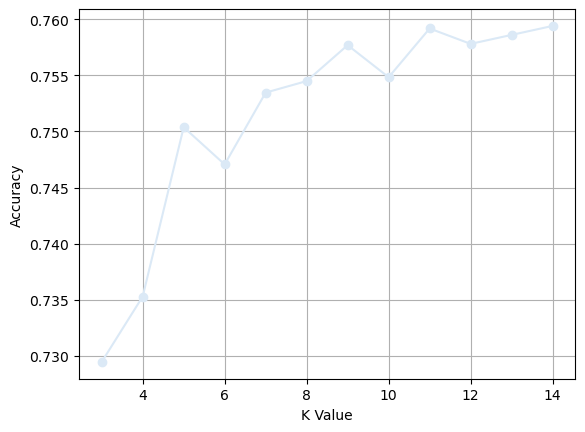

In [ ]:
plt.plot(neighbors,k_metric,'o-')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.grid()
plt.show()

In [ ]:
k_model11=KNeighborsClassifier(n_neighbors=11,metric='euclidean')
k_model11=k_model11.fit(xtrain,ytrain)
k_ypred11=k_model11.predict(xtest)
k_acc11=accuracy_score(ytest,k_ypred11)
k_acc11

0.7591724768544976

In [ ]:
k_model14=KNeighborsClassifier(n_neighbors=14,metric='euclidean')
k_model14=k_model14.fit(xtrain,ytrain)
k_ypred14=k_model14.predict(xtest)
k_acc14=accuracy_score(ytest,k_ypred14)
k_acc14

0.7594010744085038

<div style="
    background: linear-gradient(135deg, rgba(21, 198, 195, 0.6), #08add6ff);
    color: #153fa8;
    font-weight: bold;
    padding: 24px 20px;
    border-radius: 18px;
    text-align: left;
    font-size: 28px;
    letter-spacing: 1.8px;
    text-transform: uppercase;
    box-shadow: 0 3px 12px rgba(15, 10, 71, 0.5);
    text-shadow: 0 0 1px #d5d5d5ff, 0 0 3px #0f0a47;
    border: 2px solid rgba(255, 255, 255, 0.12);
">
GRADIENT BOOST        
</div>

In [ ]:
g_model=GradientBoostingClassifier(learning_rate=0.2,n_estimators=100,max_depth=4)
g_model=g_model.fit(xtrain,ytrain)

In [ ]:
g_ypred=g_model.predict(xtest)
g_acc=accuracy_score(ytest,g_ypred)
g_acc

0.8993027774602812

<div style="
    background: linear-gradient(135deg, rgba(21, 198, 195, 0.6), #08add6ff);
    color: #153fa8;
    font-weight: bold;
    padding: 24px 20px;
    border-radius: 18px;
    text-align: left;
    font-size: 28px;
    letter-spacing: 1.8px;
    text-transform: uppercase;
    box-shadow: 0 3px 12px rgba(15, 10, 71, 0.5);
    text-shadow: 0 0 1px #d5d5d5ff, 0 0 3px #0f0a47;
    border: 2px solid rgba(255, 255, 255, 0.12);
">
TABLE        
</div>

In [ ]:
table=[['MODEL','ACCURACY'],['LOGISTIC REGRESSION',lo_acc],
       ['RANDOM FOREST',rf_acc],
       ['DECISION TREE',d_acc],
       ['SVM :- LINEAR',s_acc],
       ['SVM :- NON-LINEAR',s2_acc],
       ['XGBOOST',x_acc],
       ['CATBOOST',c_acc],
       ['LGBOOST',lg_acc],
       ['KNN',k_acc14],
       ['GRADIENT',g_acc]]

print(tabulate(table,headers='firstrow',tablefmt='fancy_grid'))

╒═════════════════════╤════════════╕
│ MODEL               │   ACCURACY │
╞═════════════════════╪════════════╡
│ LOGISTIC REGRESSION │   0.851869 │
├─────────────────────┼────────────┤
│ RANDOM FOREST       │   0.902846 │
├─────────────────────┼────────────┤
│ DECISION TREE       │   0.749228 │
├─────────────────────┼────────────┤
│ SVM :- LINEAR       │   0.858727 │
├─────────────────────┼────────────┤
│ SVM :- NON-LINEAR   │   0.839867 │
├─────────────────────┼────────────┤
│ XGBOOST             │   0.892559 │
├─────────────────────┼────────────┤
│ CATBOOST            │   0.899531 │
├─────────────────────┼────────────┤
│ LGBOOST             │   0.892216 │
├─────────────────────┼────────────┤
│ KNN                 │   0.759401 │
├─────────────────────┼────────────┤
│ GRADIENT            │   0.899303 │
╘═════════════════════╧════════════╛


<div style="
    background: linear-gradient(135deg, #0f0a47, #153fa8);
    color: #d8f3ee;
    font-weight: bold;
    padding: 24px 20px;
    border-radius: 10px;
    text-align: center;
    font-size: 35px;
    letter-spacing: 1.8px;
    text-transform: uppercase;
    box-shadow: 0 3px 12px rgba(15, 10, 71, 0.5);
    text-shadow: 0 0 2px #c4e600, 0 0 6px rgba(196, 230, 0, 0.6);
    border: 2px solid rgba(255, 255, 255, 0.12);
">
   HYPERPARAMETER TUNING
</div>


In [ ]:
rf=RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}


In [ ]:
grid_search=GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)

In [ ]:
grid_search.fit(xtrain,ytrain)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 300]},
             verbose=2)

In [ ]:
print('Best Hyperparameters : ')
print(grid_search.best_params_)
print('Best Accuracy : ',grid_search.best_score_)

Best Hyperparameters : 
{'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Best Accuracy :  0.9001000142877554


In [ ]:
final_model=RandomForestClassifier(random_state=42,max_depth=20,max_features='sqrt',min_samples_leaf=1,min_samples_split=5,n_estimators=100)
final_model=final_model.fit(xtrain,ytrain)

In [ ]:
final_ypred=final_model.predict(xtest)
final_acc=accuracy_score(ytest,final_ypred)
final_acc

0.9035318322093954

<div style="
    background: linear-gradient(135deg, rgba(21, 198, 195, 0.6), #08add6ff);
    color: #153fa8;
    font-weight: bold;
    padding: 24px 20px;
    border-radius: 18px;
    text-align: left;
    font-size: 28px;
    letter-spacing: 1.8px;
    text-transform: uppercase;
    box-shadow: 0 3px 12px rgba(15, 10, 71, 0.5);
    text-shadow: 0 0 1px #d5d5d5ff, 0 0 3px #0f0a47;
    border: 2px solid rgba(255, 255, 255, 0.12);
">
METRICS        
</div>

In [ ]:
pre=precision_score(ytest,final_ypred,average='macro')
pre

0.9046277292138261

In [ ]:
f1=f1_score(ytest,final_ypred,average='macro')
f1

0.9035575788035328

In [ ]:
rec=recall_score(ytest,final_ypred,average='macro')
rec

0.9037115423766381

In [ ]:
y_pred = final_model.predict(xtest)
y_prob = final_model.predict_proba(xtest)


roc_auc = roc_auc_score(ytest, y_prob, multi_class="ovr")
print("\nROC AUC SCORE :", roc_auc)


ROC AUC SCORE : 0.9973219513479652


In [ ]:
print("\nClassification Report:")
print(classification_report(ytest, final_ypred))


Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.89      0.92       531
           1       0.94      0.86      0.90       517
           2       0.93      0.90      0.92       559
           3       0.92      0.84      0.88       571
           4       0.88      0.90      0.89       532
           5       0.90      0.90      0.90       547
           6       0.94      0.92      0.93       588
           7       0.90      0.91      0.90       555
           8       0.93      0.91      0.92       540
           9       0.89      0.91      0.90       558
          10       0.94      0.91      0.92       550
          11       0.87      0.87      0.87       551
          12       0.87      0.92      0.89       574
          13       0.87      0.91      0.89       513
          14       0.89      0.97      0.93       509
          15       0.86      0.93      0.89       554

    accuracy                           0.90      8749
  

In [ ]:
y_pred = final_model.predict(xtest)
y_prob = final_model.predict_proba(xtest)

print("Confusion Matrix:\n", confusion_matrix(ytest, y_pred))

Confusion Matrix:
 [[474   0   0   0  22   0   0   0  34   0   0   0   1   0   0   0]
 [  1 443   0   1   0  20   0   0   0  50   0   0   0   2   0   0]
 [  0   0 503   2   0   0  20   0   0   0  30   0   0   0   4   0]
 [  0   0   1 482   0   0   0  21   0   0   0  66   0   0   0   1]
 [  3   0   0   0 477   0   0   0   0   0   0   0  52   0   0   0]
 [  0   5   0   0   0 492   0   0   0   0   0   0   0  50   0   0]
 [  0   0   7   0   0   0 542   0   0   0   0   0   0   0  39   0]
 [  0   0   0   7   0   0   1 505   0   0   0   0   0   0   0  42]
 [ 22   0   0   0   1   0   0   0 493   0   0   0  24   0   0   0]
 [  0  24   0   2   0   3   0   0   0 510   0   0   0  19   0   0]
 [  0   0  27   0   0   0   3   0   0   0 500   1   0   0  19   0]
 [  0   0   0  30   0   0   0   1   0   2   0 479   0   0   0  39]
 [  0   0   0   0  44   0   0   0   2   0   0   0 527   1   0   0]
 [  0   0   0   0   0  31   0   0   0  13   0   0   0 469   0   0]
 [  0   0   0   0   0   0  10   0   0   0  

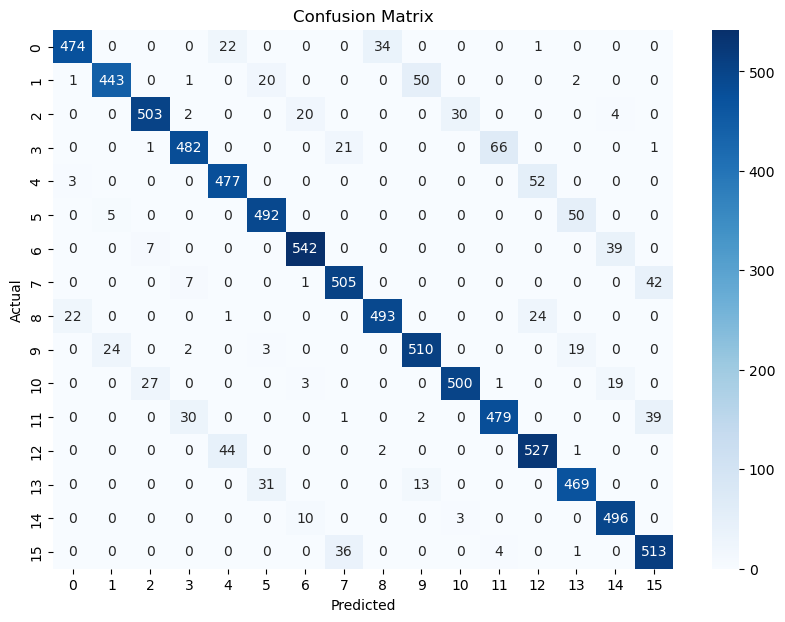

In [ ]:
cm = confusion_matrix(ytest, final_ypred)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

<div style="
    background: linear-gradient(135deg, #0f0a47, #153fa8);
    color: #d8f3ee;
    font-weight: bold;
    padding: 24px 20px;
    border-radius: 10px;
    text-align: center;
    font-size: 35px;
    letter-spacing: 1.8px;
    text-transform: uppercase;
    box-shadow: 0 3px 12px rgba(15, 10, 71, 0.5);
    text-shadow: 0 0 2px #c4e600, 0 0 6px rgba(196, 230, 0, 0.6);
    border: 2px solid rgba(255, 255, 255, 0.12);
">
   PREDICTION
</div>

In [ ]:
new_col=['Age','Gender','Education','Introversion Score','Sensing Score','Thinking Score','Judging Score','Interest']
new_pn=pd.DataFrame([[21.0,'Female',1,5.89208,2.144395,7.32363,5.462224,'Arts']],columns=new_col)

new_pn['Gender']=le.transform(new_pn['Gender'])
new_pn=pd.get_dummies(new_pn,columns=['Interest'],drop_first=False)
new_pn=new_pn.reindex(columns=x.columns, fill_value=0)

scaled_pn=scaler.transform(new_pn)

z=final_model.predict(scaled_pn)[0]
labels={ 3:'ENTP', 11:'INTP', 5:'ESFP', 0:'ENFJ', 13:'ISFP', 12:'ISFJ', 6:'ESTJ', 9:'INFP', 7:'ESTP', 1:'ENFP', 10:'INTJ', 4:'ESFJ', 14:'ISTJ', 8:'INFJ', 15:'ISTP', 2:'ENTJ'}
print(labels.get(z))

ENTP
